In [1]:
# load netcdf from OM4 runs

import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colorbar import ColorbarBase


/home/abodner/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [6]:
# paths to dataset
BASE = '/orcd/data/abodner/002/shared_datasets/om4_output/new_runs/'


# load FK MLD data 
ds_MLD_EN1_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN1.nc')
ds_MLD_EN2_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN2.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_FK = ds_MLD_EN1_FK.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(0,503))
MLD_winter_SH_FK = ds_MLD_EN2_FK.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(0,503))

# Northern Hemisphere (NH)
MLD_summer_NH_FK = ds_MLD_EN1_FK.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(503,1080))
MLD_winter_NH_FK = ds_MLD_EN2_FK.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(503,1080))

# concat SH and NH for summer and winter datasets
GFDL_MLD_BFF11_summer = xr.concat([MLD_summer_SH_FK, MLD_summer_NH_FK], "yh")
GFDL_MLD_BFF11_winter = xr.concat([MLD_winter_SH_FK, MLD_winter_NH_FK], "yh")


# load BD MLD data 
ds_MLD_EN1_BD = xr.open_dataset(BASE+'BOD23/ocean_monthly.201801-202212.MLD_EN1.nc')
ds_MLD_EN2_BD = xr.open_dataset(BASE+'BOD23/ocean_monthly.201801-202212.MLD_EN2.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_BD = ds_MLD_EN1_BD.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(0,503))
MLD_winter_SH_BD = ds_MLD_EN2_BD.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(0,503))

# Northern Hemisphere (NH)
MLD_summer_NH_BD = ds_MLD_EN1_BD.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(503,1080))
MLD_winter_NH_BD = ds_MLD_EN2_BD.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(503,1080))

# concat SH and NH for summer and winter datasets
GFDL_MLD_BOD23_summer = xr.concat([MLD_summer_SH_BD, MLD_summer_NH_BD], "yh")
GFDL_MLD_BOD23_winter = xr.concat([MLD_winter_SH_BD, MLD_winter_NH_BD], "yh")




# load no-MLE MLD data 
ds_MLD_EN1_NO = xr.open_dataset(BASE+'noMLE/ocean_monthly.201801-202212.MLD_EN1.nc')
ds_MLD_EN2_NO = xr.open_dataset(BASE+'noMLE/ocean_monthly.201801-202212.MLD_EN2.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_NO = ds_MLD_EN1_NO.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(0,503))
MLD_winter_SH_NO = ds_MLD_EN2_NO.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(0,503))

# Northern Hemisphere (NH)
MLD_summer_NH_NO = ds_MLD_EN1_NO.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(503,1080))
MLD_winter_NH_NO = ds_MLD_EN2_NO.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(503,1080))

# concat SH and NH for summer and winter datasets
GFDL_MLD_noMLE_summer = xr.concat([MLD_summer_SH_NO, MLD_summer_NH_NO], "yh")
GFDL_MLD_noMLE_winter = xr.concat([MLD_winter_SH_NO, MLD_winter_NH_NO], "yh")


# load static file
#ds_stat = xr.open_dataset(BASE+'ocean_annual_z.static.nc')

/tmp/ipykernel_16795/707407612.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_MLD_EN1_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN1.nc')
/tmp/ipykernel_16795/707407612.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_MLD_EN2_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN2.nc')
/tmp/ipykernel_16795/707407612.py:24: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_MLD_EN1_BD = xr.open_dataset(BASE+'BOD23/ocean_monthly.201801-202212.MLD_EN1.nc')
/tmp/ipykernel_16795/707407612.py

In [8]:
def enable_global(tlon,tlat,data):
  """Fix the data in such a way that it can to be plotted on a global projection on its native grid"""
  tlon = np.where(np.greater_equal(tlon,min(tlon[:,0])),tlon-360,tlon)
  tlon=tlon+abs(np.max(tlon)); tlon=tlon+360
  # stack grids side-by-side (in longitiudinal direction), so
  # any range of longitudes may be plotted on a world map.
  tlon = np.concatenate((tlon,tlon+360),1)
  tlat = np.concatenate((tlat,tlat),1)
  data = np.concatenate((data,data),1)
  tlon = tlon-360.
  tlon -= 110.0
  return tlon, tlat, data



## plot MLD 

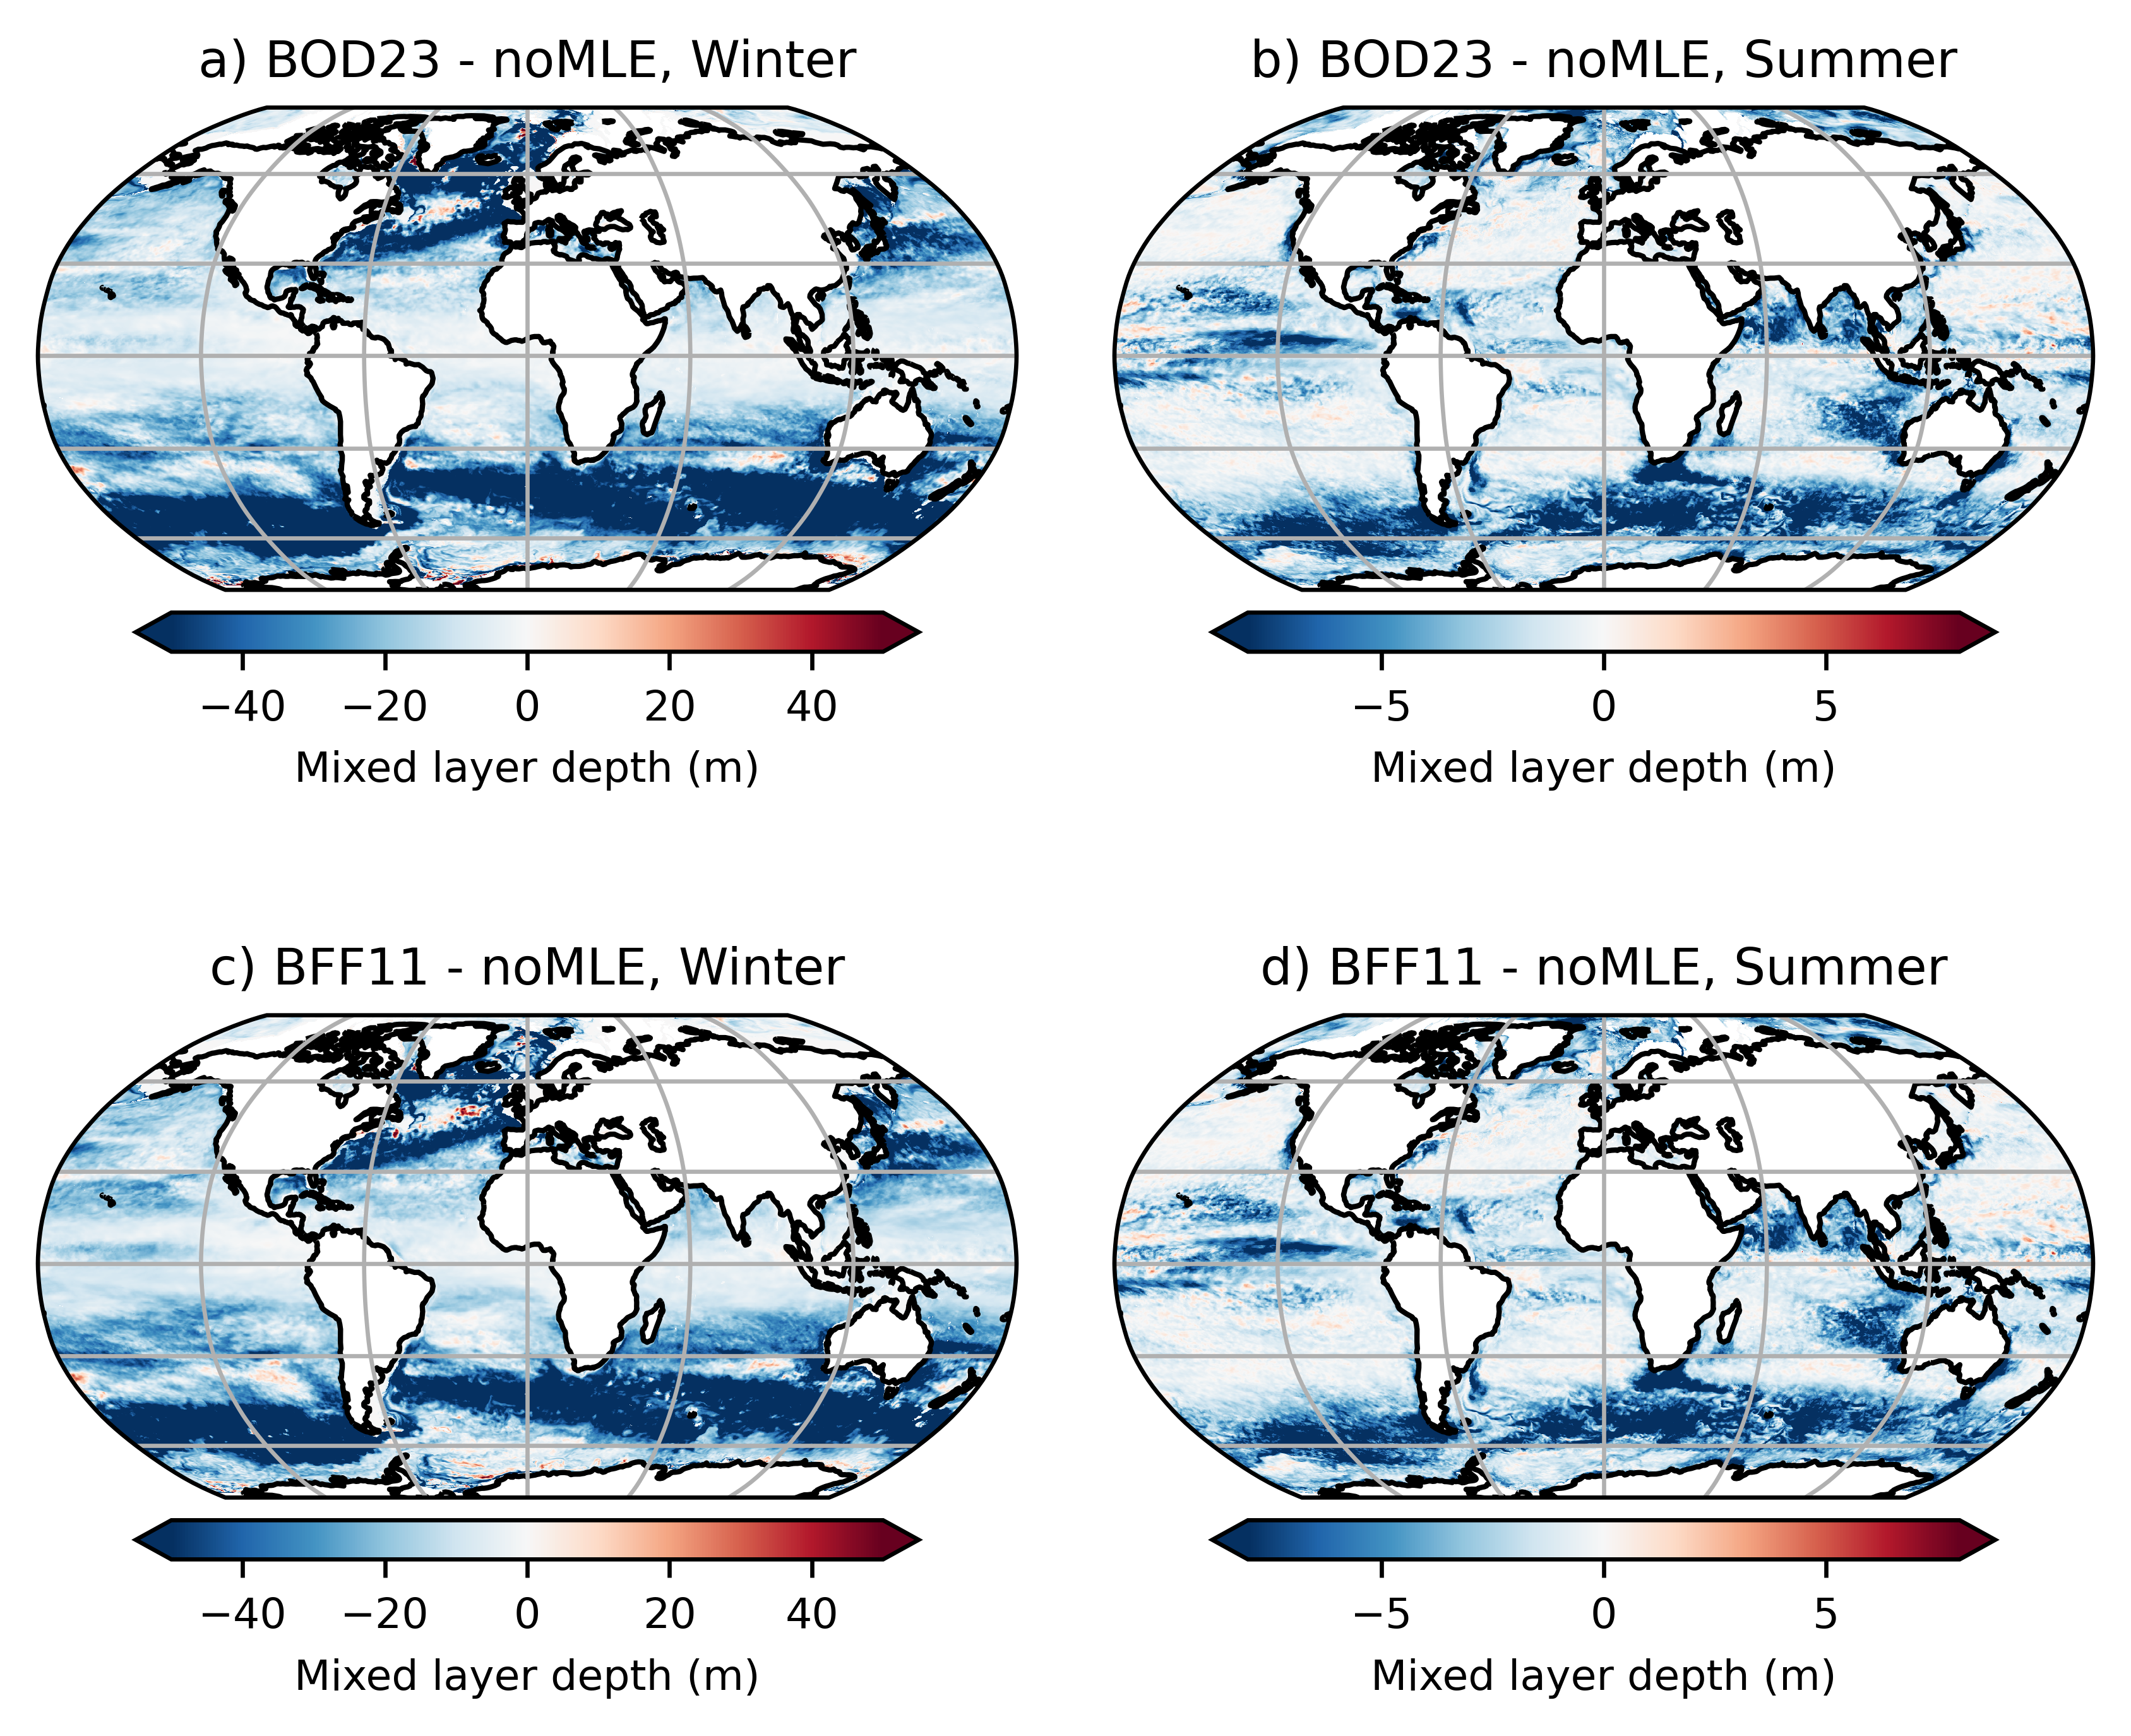

In [14]:
# create a figure
#fig = plt.figure()
fig, ax = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        figsize=(7,7), dpi=600)

ax=ax.flatten()
plt.subplots_adjust(wspace=0.1, hspace=0.1)


cbar_lim_winter = 50  
cbar_lim_summer = 8  

# MLD BD minus noMLE winter GFDL
i_ax = 0

(GFDL_MLD_BOD23_winter - GFDL_MLD_noMLE_winter).rename('Mixed layer depth (m)').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim_winter,
    vmax=cbar_lim_winter,          
    cmap="RdBu_r",  
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8,'extend':'both'},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('a) BOD23 - noMLE, Winter')


# MLD BD minus noMLE summer GFDL
i_ax = 1
(GFDL_MLD_BOD23_summer - GFDL_MLD_noMLE_summer).rename('Mixed layer depth (m)').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim_summer,
    vmax=cbar_lim_summer,          
    cmap="RdBu_r", 
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8,'extend':'both'},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('b) BOD23 - noMLE, Summer')


# MLD BFF minus noMLE winter GFDL
i_ax = 2

(GFDL_MLD_BFF11_winter - GFDL_MLD_noMLE_winter).rename('Mixed layer depth (m)').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim_winter,
    vmax=cbar_lim_winter,          
    cmap="RdBu_r",  
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8,'extend':'both'},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('c) BFF11 - noMLE, Winter')


# MLD BFF minus noMLE summer GFDL
i_ax = 3
(GFDL_MLD_BOD23_summer - GFDL_MLD_noMLE_summer).rename('Mixed layer depth (m)').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim_summer,
    vmax=cbar_lim_summer,          
    cmap="RdBu_r", 
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8,'extend':'both'},
)

ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('d) BFF11 - noMLE, Summer')




plt.rcParams.update({'font.size': 8})
plt.subplots_adjust(wspace=0.1, hspace=-0.2)

# save figure
plt.savefig('./figures/MLD_diff_noMLE_GFDL')
